In [1]:
import pandas as pd
import numpy as np
import os,sys
import matplotlib.pyplot as plt
from astropy import units as u
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from class_analysis import Analysis_Event
from Sim_Fit_Event import simulation_event
from ulens_params import microlensing_params
current_path = '../roman_rubin/'
path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'

script_dir = 'microlensing/simulation_Rubin/roman_rubin/'
ra, dec= 267.92497054815516, -29.152232510353276
system_type = 'lenses_low_mass'
model = 'FSPL'
orbital_period = 0
ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
      'i': 27.85, 'z': 27.46, 'y': 26.68}


/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/class_analysis.py:37: SyntaxWarning: invalid escape sequence '\D'
  axes[2,0].set_ylabel("$\Delta \mathrm{mag}$\nRoman",fontsize=16)
/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/class_analysis.py:38: SyntaxWarning: invalid escape sequence '\D'
  axes[1,0].set_ylabel("$\Delta \mathrm{mag}$\nRoman+Rubin",fontsize=16)
/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/class_analysis.py:492: SyntaxWarning: invalid escape sequence '\s'
  constant flux by more than 3$\sigma$


/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/Sim_Fit_Event.py:738: SyntaxWarning: invalid escape sequence '\s'
  constant flux by more than 3$\sigma$


microlensing/simulation_Rubin/roman_rubin/


  0%|          | 0/1 [00:00<?, ?it/s]

Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS


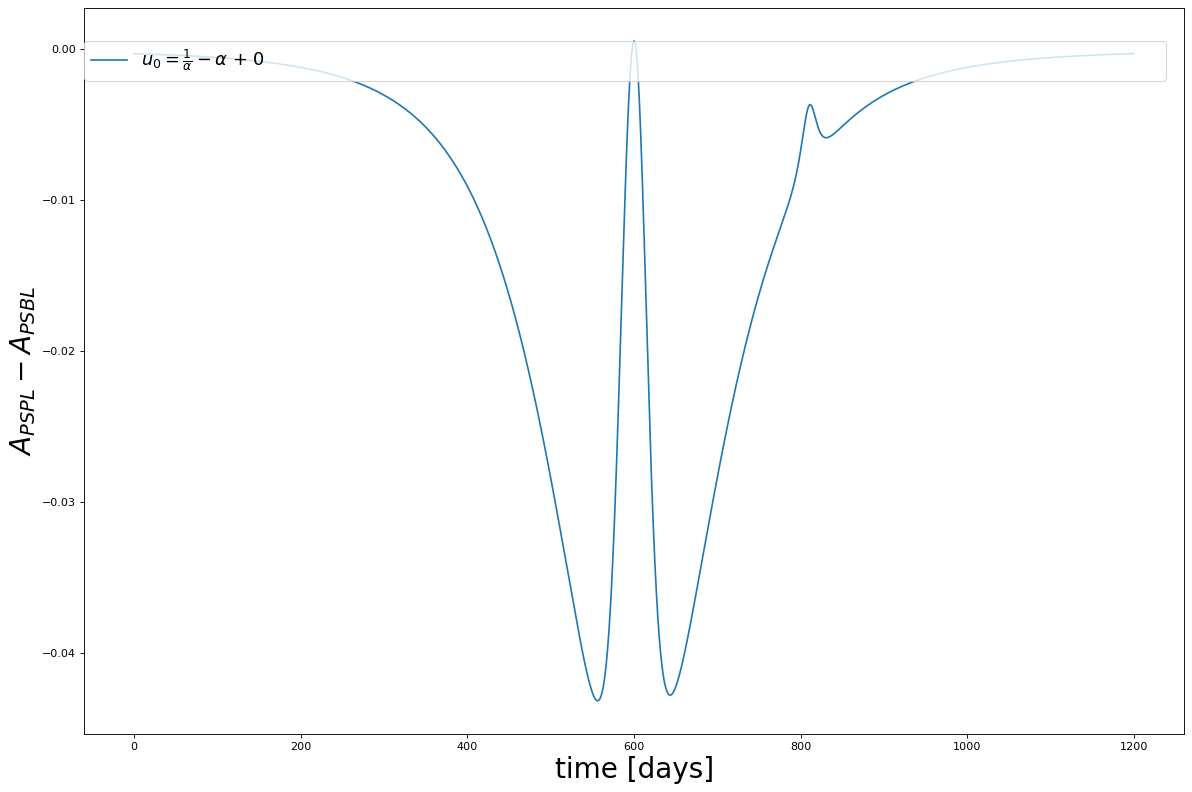

In [5]:
from tqdm.auto import tqdm
import h5py
j=1
GENULENS_file =f"Genulens_chunk_{j}.csv"
TRILEGAL_file =f"TRILEGAL_chunk_{j}.csv"
print(str(script_dir))
path_TRILEGAL_set ='/home/anibal-pc/'+str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+TRILEGAL_file 
path_GENULENS_set ='/home/anibal-pc/'+str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+GENULENS_file 
system_type = 'lenses_low_mass'
model = 'PSBL'
orbital_period = 0
ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
      'i': 27.85, 'z': 27.46, 'y': 26.68}

cols = ['Seed','mass','tE','rho','flag_roman','flag_ODI']
# df = pd.DataFrame(columns=cols)
output_path='/home/anibal-pc/proposal_odi/output.csv'
# pd.DataFrame(columns=cols).to_csv(output_path, index=False)


# for i in tqdm(range(1000)):
i=1
ROW = i-5000*int(i/5000)
seed = i

TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns

GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1,header=None)  
GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns

event_bin = simulation_event(ra, dec, i, path_ephemerides, path_dataslice,
                    TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type, 'PSBL', 0, 'test')
event_ps = simulation_event(ra, dec, i, path_ephemerides, path_dataslice,
                    TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type, 'PSPL', 0, 'test')

timestamps = np.arange(0,1200,1/50)

s=0.4
plt.close("all")
plt.figure(figsize=(15,10),dpi=80)
from tqdm.auto import tqdm
for deltau in tqdm([0]):#np.linspace(-0.2,0.2,5)):
    event_params = {'t0': 600, 'u0': (1/s) -s+deltau, 'tE': 70,
                                      's': s, 'q': 0.05/0.2, 'alpha': np.pi/2
                                      }
    
    Event_bin = event_bin.Event_Rubin_custom_cadence({'g':timestamps})
    Event_ps = event_ps.Event_Rubin_custom_cadence({'g':timestamps})
    my_own_model2, pyLIMA_parameters = event_bin.sim_clear_Rubin_lightcurves(Event_bin, event_params)
    my_own_model1, pyLIMA_parameters1 = event_ps.sim_clear_Rubin_lightcurves(Event_ps, event_params)
  
    A_bin = my_own_model2.model_magnification(my_own_model2.event.telescopes[0],pyLIMA_parameters)
    A_ps = my_own_model1.model_magnification(my_own_model1.event.telescopes[0],pyLIMA_parameters1)
    

    plt.plot(my_own_model1.event.telescopes[0].lightcurve['time'], A_ps-A_bin,label=r'$u_0 = \frac{1}{\alpha}-\alpha$' + f' + {str(round(deltau,3))}' )


plt.ylabel("$A_{PSPL}-A_{PSBL}$",fontsize=25)
plt.xlabel('time [days]',fontsize=25)
plt.legend(loc=(0,0.9), ncol=5, fontsize=16, mode="expand")
# legend(shadow=True, fontsize='large',
                                # bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                                # mode="expand", borderaxespad=0, ncol=3, numpoints=1)
plt.tight_layout()
plt.show()

In [7]:
pars2=[event_params[p] for p in ['t0', 'u0', 'tE', 's', 'q', 'alpha'] ]
pars1=[event_params[p] for p in ['t0', 'u0', 'tE'] ]
pars=[pyLIMA_parameters[p] for p in ['t_center', 'u_center', 'tE', 'separation', 'mass_ratio', 'alpha'] ]

/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/pyLIMA/outputs/pyLIMA_plots.py:307: RuntimeWarning: divide by zero encountered in scalar divide
  derivative = (trajectory_y[index - 1] - trajectory_y[index + 1]) / (
/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/pyLIMA/outputs/pyLIMA_plots.py:315: RuntimeWarning: invalid value encountered in scalar multiply
  trajectory_y[index] - (


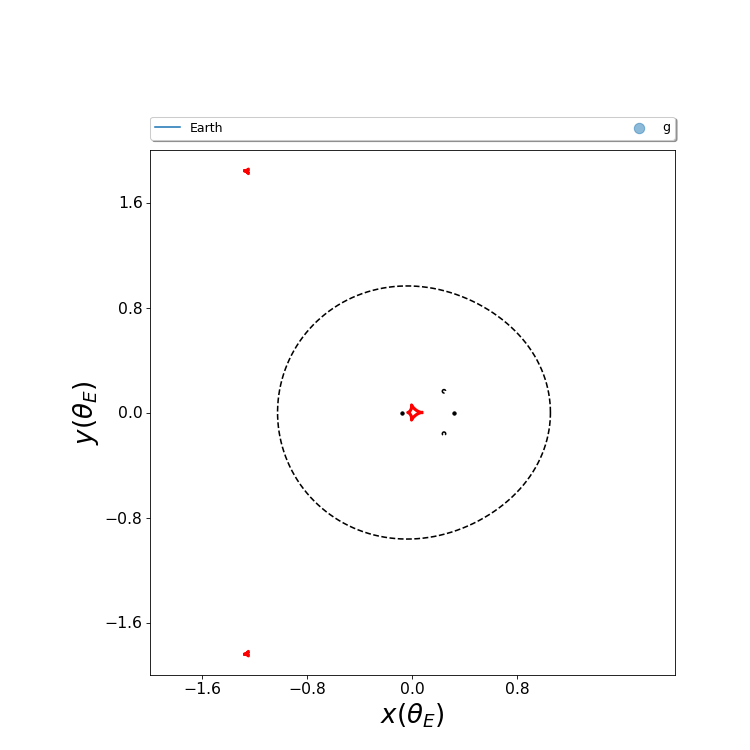

In [8]:
from pyLIMA.outputs import pyLIMA_plots

%matplotlib widget
plt.close('all')
figure_trajectory, bokeh_geometry = pyLIMA_plots.plot_geometry(my_own_model2, pars2)